<a href="https://colab.research.google.com/github/parthakk07/ML-learnings/blob/main/ch_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [ ]:
fashion_MNIST=keras.datasets.fashion_mnist
(X_train_full,y_train_full),(X_test,Y_test)=fashion_MNIST.load_data()
print(X_train_full.shape)
print(X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [ ]:
X_train_val=X_train_full[:5000]/255.0
X_train_full=X_train_full[5000:]/255.0
y_val=y_train_full[:5000]
y_train_full=y_train_full[5000:]
print(X_train_full.shape)
print(X_train_val.shape)
print(X_test.shape)

(55000, 28, 28)
(5000, 28, 28)
(10000, 28, 28)


In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print(y_train_full[0])

4


In [ ]:
from tensorflow.keras import Sequential
model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])
# model.comple() - used for telling hoiw to train the model
# which loss function and meetrics , optimizer , batch size=32 default (1-> sgd , rows-batch)
# class weights - for larger weights to underrepresentred classes and lower to overpresented classes
# sample weights for pre instance weights
history=model.fit(X_train_full,y_train_full,epochs=50,validation_data=(X_train_val,y_val))

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7611 - loss: 0.7271 - val_accuracy: 0.8324 - val_loss: 0.5148
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8289 - loss: 0.4883 - val_accuracy: 0.8460 - val_loss: 0.4515
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8463 - loss: 0.4410 - val_accuracy: 0.8592 - val_loss: 0.4167
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8545 - loss: 0.4141 - val_accuracy: 0.8640 - val_loss: 0.4017
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8617 - loss: 0.3928 - val_accuracy: 0.8626 - val_loss: 0.3956
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8668 - loss: 0.3765 - val_accuracy: 0.8604 - val_loss: 0.3827
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8712 - loss: 0.3626 - val_accuracy: 0.8730 - val_loss: 0.3621
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8743 - loss: 0.3

In [ ]:
hidden1=model.layers[1]
weights,biases=hidden1.get_weights()
print(weights.shape)
print(weights)

(784, 300)
[[ 0.06162728  0.00997564  0.00726773 ...  0.04693741  0.07238225
   0.05809738]
 [-0.06516565  0.05792033  0.01227402 ...  0.04637034  0.00892584
  -0.01679443]
 [ 0.04034254  0.05211831  0.05567302 ...  0.01913335  0.04099993
   0.04454985]
 ...
 [-0.02420489  0.06691886  0.05461896 ... -0.07333325  0.01729473
  -0.00455211]
 [ 0.05769422 -0.05463636 -0.0299793  ... -0.01998309  0.04681928
   0.04759625]
 [ 0.02603498  0.01640438 -0.0556134  ...  0.01505851 -0.06712549
   0.02640415]]


In [ ]:
print(history.history)

{'accuracy': [0.7611091136932373, 0.8289272785186768, 0.8462545275688171, 0.8544909358024597, 0.8617454767227173, 0.8668363690376282, 0.8712363839149475, 0.8742727041244507, 0.8770363926887512, 0.8811636567115784, 0.8839454650878906, 0.8868727087974548, 0.8880727291107178, 0.8921090960502625, 0.8933454751968384, 0.8945090770721436, 0.8968726992607117, 0.8988363742828369, 0.9024909138679504, 0.902999997138977, 0.9034727215766907, 0.9058545231819153, 0.9064909219741821, 0.9100363850593567, 0.9106545448303223, 0.9125818014144897, 0.914654552936554, 0.9148181676864624, 0.9162909388542175, 0.9170545339584351, 0.9195818305015564, 0.9211454391479492, 0.9229272603988647, 0.9237454533576965, 0.9239636659622192, 0.9261817932128906, 0.9278727173805237, 0.9281272888183594, 0.929345428943634, 0.9314000010490417, 0.9320726990699768, 0.9330182075500488, 0.9336727261543274, 0.9357818365097046, 0.9364363551139832, 0.9374727010726929, 0.9386000037193298, 0.9401272535324097, 0.9400908946990967, 0.9421272

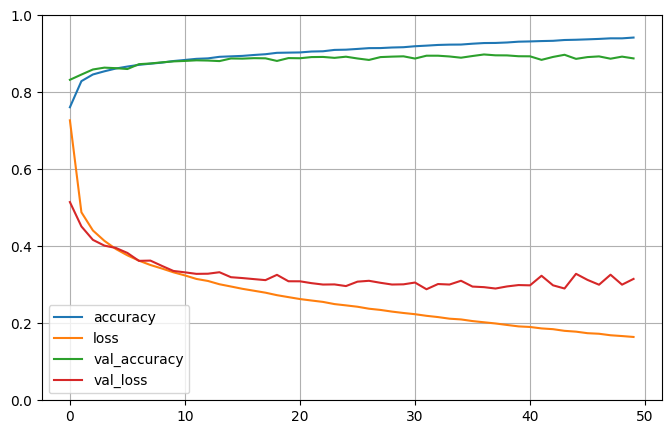

In [ ]:
# learning curve
# val accuracy is close to traning curve accuracy - overfitting sign
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [ ]:
model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8472 - loss: 71.3863


[71.3863296508789, 0.8471999764442444]

In [ ]:
# not good result
# try different optimizers or tune hyperparameters nmber of layers , neurons per layers activation function
# some batch size ,

In [ ]:
model.save("awesome_model.keras")

In [ ]:
X_new=X_test[:3]
y_prob=model.predict(X_new)
print(y_prob)
print(class_names[np.argmax(y_prob[0])])
print(class_names[np.argmax(y_prob[1])])
print(class_names[np.argmax(y_prob[2])])
y_pred=y_prob.argmax(axis=-1)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Ankle boot
Pullover
Trouser
[9 2 1]


In [ ]:
# predict_proba()

In [ ]:
# regression MLP using sequential api
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing=fetch_california_housing()
X_train_full,X_test,y_train_full,y_test=train_test_split(housing.data,housing.target)
X_train,X_val,y_train,y_val=train_test_split(X_train_full,y_train_full)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)
X_val=sc.transform(X_val)

In [ ]:
model=keras.models.Sequential([
    keras.layers.Dense(50,activation="relu",input_shape=X_train.shape[1:]),
    keras.layers.Dense(50,activation="relu"),
    keras.layers.Dense(50,activation="relu"),
    keras.layers.Dense(1)
])
model.compile(loss="mean_squared_error",optimizer="Adam",metrics=["RootMeanSquaredError"])
history=model.fit(X_train,y_train,epochs=20,validation_data=(X_val,y_val))
mse_test=model.evaluate(X_test,y_test)
X_new=X_test[:3]
y_pred=model.predict(X_new)
print(y_pred)

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - RootMeanSquaredError: 0.9593 - loss: 0.9202 - val_RootMeanSquaredError: 0.6500 - val_loss: 0.4225
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 0.6385 - loss: 0.4076 - val_RootMeanSquaredError: 0.6023 - val_loss: 0.3628
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6102 - loss: 0.3724 - val_RootMeanSquaredError: 0.5934 - val_loss: 0.3521
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5950 - loss: 0.3540 - val_RootMeanSquaredError: 0.5911 - val_loss: 0.3494
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5910 - loss: 0.3493 - val_RootMeanSquaredError: 0.5780 - val_loss: 0.3341
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5758 - loss: 0.3315 - val_RootMeanSquaredError: 0.5662 - val_loss: 0.3206
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 0.5640 - loss: 0.3181 -

In [ ]:
# complex model -> wide deep learning (for recommender system ) using two models wide and deep nn in nutshell
# wide is model which feed on data (memoriziation) like iinput is present in data
# deep nn is model which gueses or predict (generalization) like predicting output on based of data
# Concat + one output + one loss = joint training

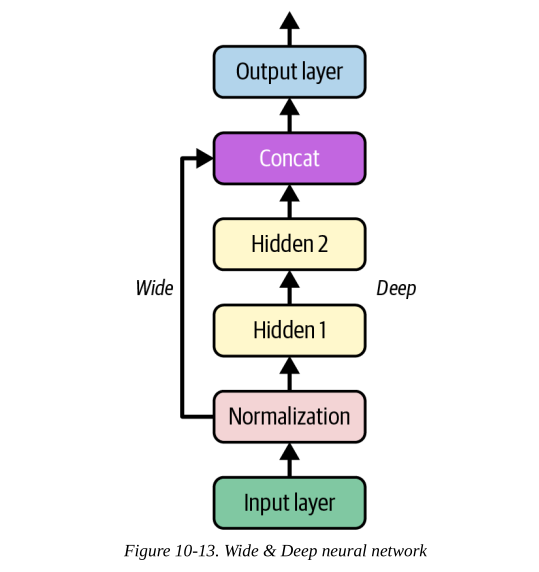

In [ ]:
input = keras.layers.Input(shape=X_train.shape[1:])

normilization=tf.keras.layers.Normalization()(input)
hidden1=keras.layers.Dense(30,activation="relu")(normilization)
hidden2=keras.layers.Dense(30,activation="relu")(hidden1)
concat=keras.layers.Concatenate()([normilization,hidden2])
output=keras.layers.Dense(1)(concat)
model=keras.Model(inputs=[input],outputs=[output])
model.compile(loss="mse",optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [ ]:
history=model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))
mse_test=model.evaluate(X_test,y_test)
y_pred=model.predict(X_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.8806 - val_loss: 0.7931
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7494 - val_loss: 0.6826
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6715 - val_loss: 0.6437
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6345 - val_loss: 0.6082
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6068 - val_loss: 0.5814
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5832 - val_loss: 0.5591
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5658 - val_loss: 0.5400
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5498 - val_loss: 0.5237
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5373 - val_loss: 0.5113
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5263 - val_loss: 0.5016
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5172 - val_loss: 0.4926
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [ ]:
# saving and restoring the model
model.save("nodel.h5") # HDF5 - model and its architecture and logic(.pb)

In [ ]:
# callbacks
# early stopping - best_only=True
checkpoint= tf.keras.callbacks.ModelCheckpoint("my_checkpoints",save_weights_only=True)
history model.fit([X_train,y_train],callbacks=[checkpoint])